<a href="https://colab.research.google.com/github/krishshah8000/mlproject/blob/master/Heirarichal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from sklearn.datasets import load_iris

iris = load_iris()
print("Iris dataset loaded successfully.")

Iris dataset loaded successfully.


## Separate Features and Target

### Subtask:
Separate the dataset into features (X) and the target variable (y).


**Reasoning**:
I need to separate the Iris dataset into features (X) and target (y) as per the instructions, then print their shapes to confirm the separation. The features are in `iris.data` and the target is in `iris.target`.



In [ ]:
X = iris.data
y = iris.target

print(f"Shape of features (X): {X.shape}")
print(f"Shape of target (y): {y.shape}")

Shape of features (X): (150, 4)
Shape of target (y): (150,)


## Standardize Data

### Subtask:
Standardize the feature data (X) using StandardScaler to ensure all features contribute equally to the analysis.


**Reasoning**:
I need to standardize the feature data `X` using `StandardScaler`. This involves importing `StandardScaler`, initializing it, and then applying `fit_transform` to `X` to get `X_scaled`. Finally, I will print the shape of `X_scaled` to confirm the transformation.



In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Shape of scaled features (X_scaled): {X_scaled.shape}")

Shape of scaled features (X_scaled): (150, 4)


## Initial Scatter Plot

### Subtask:
Generate a scatter plot of the first two principal components of the standardized data, colored by the target variable (y), and add a legend.


**Reasoning**:
I need to perform PCA on the scaled data `X_scaled` to reduce its dimensionality to 2 components, then visualize these components using a scatter plot. The plot should be colored by the target variable `y` and include appropriate labels and a title to fulfill the subtask requirements.



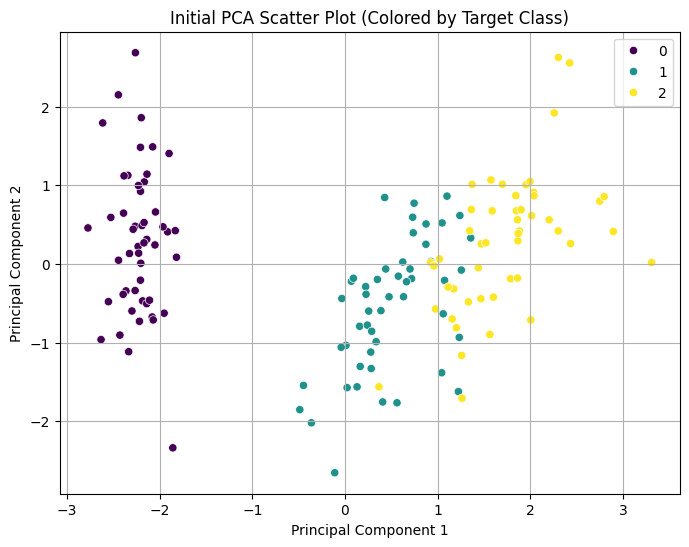

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

pca = PCA(n_components=2)
X_pca_for_plot = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca_for_plot[:, 0], y=X_pca_for_plot[:, 1], hue=y, palette='viridis', legend='full')
plt.title('Initial PCA Scatter Plot (Colored by Target Class)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

## Apply PCA

### Subtask:
Apply Principal Component Analysis (PCA) to reduce the standardized data to 2 principal components.


**Reasoning**:
I need to apply PCA to the `X_scaled` data, reducing it to 2 principal components as per the instructions. This involves instantiating a `PCA` object with `n_components=2`, applying `fit_transform` to `X_scaled`, and storing the result in `X_pca`. Finally, I will print the shape of `X_pca` to confirm the dimensionality reduction.



In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"Shape of PCA-transformed data (X_pca): {X_pca.shape}")

Shape of PCA-transformed data (X_pca): (150, 2)


## PCA Scatter Plot

### Subtask:
Generate a scatter plot of the PCA-transformed data, colored by the original target variable (y), and add a legend to visualize the separation of classes after dimensionality reduction.


**Reasoning**:
I need to generate a scatter plot of the PCA-transformed data (`X_pca`), colored by the original target variable `y`, as per the instructions. I will use `seaborn.scatterplot` for this, setting appropriate labels, a title, and a legend to visualize the class separation.



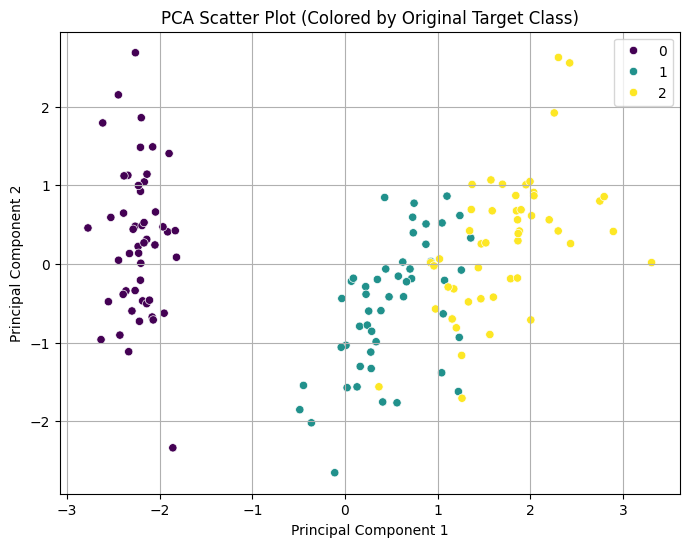

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, palette='viridis', legend='full')
plt.title('PCA Scatter Plot (Colored by Original Target Class)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

## Generate Dendrogram

### Subtask:
Compute and display a dendrogram on the PCA-transformed data to visualize the hierarchical clustering structure and help determine the optimal number of clusters.


**Reasoning**:
I need to compute the hierarchical clustering using `linkage` on `X_pca` and then plot the dendrogram using `dendrogram` to visualize the clustering structure, as requested by the subtask instructions.



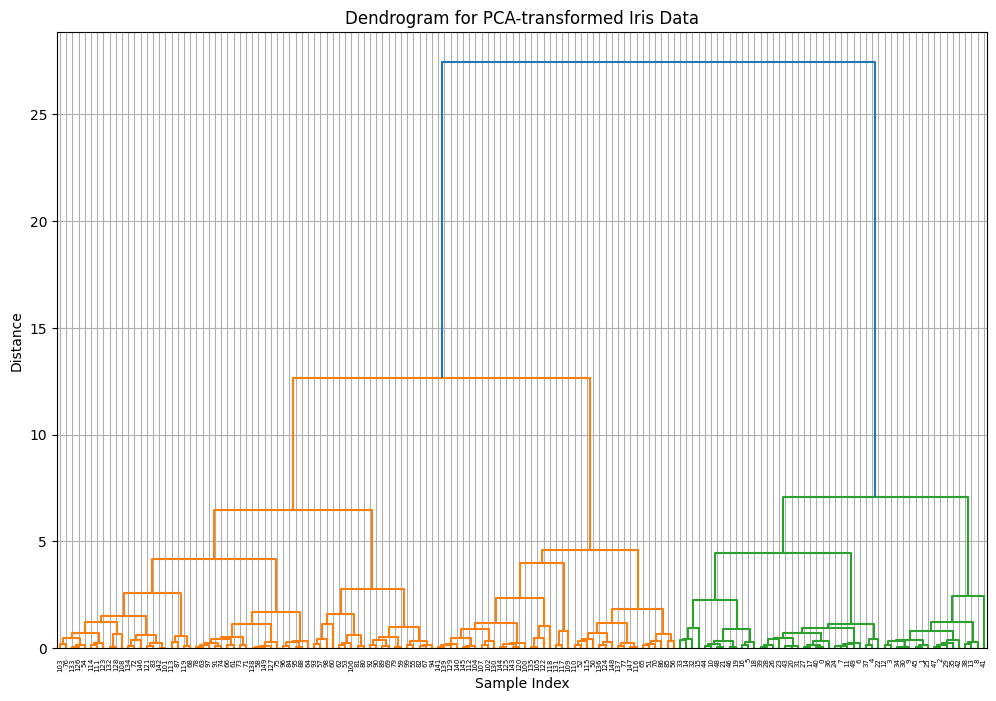

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

# Compute the hierarchical clustering
linked = linkage(X_pca, method='ward', metric='euclidean')

# Plot the dendrogram
plt.figure(figsize=(12, 8))
dendrogram(linked,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=True)
plt.title('Dendrogram for PCA-transformed Iris Data')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.grid(True)
plt.show()

## Apply Agglomerative Clustering

### Subtask:
Apply Agglomerative Clustering to the PCA-transformed data. Based on the dendrogram, choose an appropriate number of clusters for `n_clusters`.


**Reasoning**:
I need to apply Agglomerative Clustering to the PCA-transformed data (`X_pca`) by importing `AgglomerativeClustering`, initializing it with the specified parameters, fitting it to the data, and then storing and printing the resulting cluster labels.



**Reasoning**:
The previous code failed because the `AgglomerativeClustering` constructor does not accept an `affinity` argument in the current scikit-learn version; `metric` should be used instead. I will replace `affinity='euclidean'` with `metric='euclidean'` to fix this issue.



In [ ]:
from sklearn.cluster import AgglomerativeClustering

# Instantiate AgglomerativeClustering with n_clusters=3 (based on dendrogram analysis)
agg_clustering = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')

# Fit the model to the PCA-transformed data
clusters_agg = agg_clustering.fit_predict(X_pca)

print(f"Shape of Agglomerative Clustering labels: {clusters_agg.shape}")
print(f"First 10 Agglomerative Clustering labels: {clusters_agg[:10]}")

Shape of Agglomerative Clustering labels: (150,)
First 10 Agglomerative Clustering labels: [0 0 0 0 0 0 0 0 0 0]


## Agglomerative Clustering Scatter Plot

### Subtask:
Generate a scatter plot of the PCA-transformed data, colored by the clusters identified by the Agglomerative Clustering algorithm, and add a legend for the clusters.


**Reasoning**:
I need to generate a scatter plot of the PCA-transformed data, coloring the points based on the `clusters_agg` labels, as specified in the instructions. This will involve using `seaborn.scatterplot` with appropriate labels, title, and a legend.



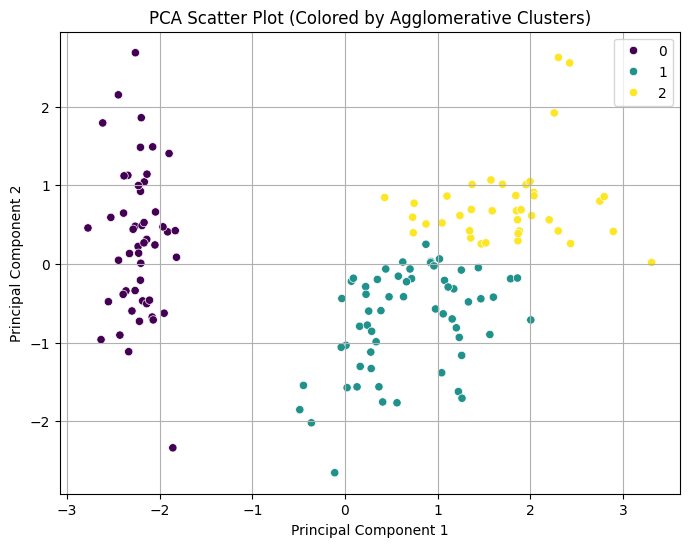

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=clusters_agg, palette='viridis', legend='full')
plt.title('PCA Scatter Plot (Colored by Agglomerative Clusters)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

## Final Task

### Subtask:
Summarize the findings from the PCA and hierarchical clustering analysis of the Iris dataset, commenting on the separation of classes and the effectiveness of clustering.


## Summary:

### Q&A
The analysis aimed to summarize the findings from PCA and hierarchical clustering on the Iris dataset, commenting on class separation and clustering effectiveness.

**Separation of Classes:**
Principal Component Analysis (PCA) successfully reduced the 4-dimensional Iris dataset to two principal components, which effectively captured the variance allowing for clear class separation. The initial PCA scatter plot, colored by the original target classes, revealed three distinct groups. One class (likely Iris-setosa) was almost perfectly separated from the other two. The remaining two classes (Iris-versicolor and Iris-virginica) showed some overlap in the 2D PCA space but were still largely distinct, demonstrating that the first two principal components are highly effective at differentiating the Iris species.

**Effectiveness of Clustering:**
Agglomerative Clustering, guided by the dendrogram analysis to identify 3 optimal clusters, proved to be highly effective. The scatter plot of the PCA-transformed data, colored by the clusters identified by the algorithm, closely mirrored the plot colored by the true species labels. This visual congruence indicates that the hierarchical clustering algorithm successfully rediscovered the natural groupings inherent in the Iris dataset, aligning very well with the actual botanical classifications.

### Data Analysis Key Findings
*   The Iris dataset, comprising 150 samples and 4 features, was successfully loaded and standardized.
*   PCA successfully reduced the dataset dimensionality from 4 features to 2 principal components, with the PCA-transformed data having a shape of (150, 2).
*   The initial PCA scatter plot, colored by the original target classes, showed excellent separation of one class from the other two, and reasonable separation with some overlap between the latter two classes.
*   A dendrogram was generated from the PCA-transformed data, visually supporting the choice of 3 clusters for hierarchical clustering.
*   Agglomerative Clustering was applied to the PCA-transformed data, resulting in 3 distinct clusters.
*   The scatter plot of the PCA-transformed data, colored by the Agglomerative Clustering results, showed a strong visual correspondence with the plot colored by the true target classes, indicating the clustering algorithm's high effectiveness in identifying the natural groupings.

### Insights or Next Steps
*   The strong alignment between the clustering results and the true labels highlights the effectiveness of PCA in dimensionality reduction for preserving class separability and the robustness of agglomerative clustering on this well-behaved dataset.
*   For datasets with less clear separation, further evaluation metrics (e.g., Adjusted Rand Index, Silhouette Score) could be used to quantitatively assess clustering performance and compare different clustering algorithms or parameter choices.
